In [ ]:
# ===============================
# Car Sales Price Prediction Notebook
# Sections:
# 1) Imports & Settings
# 2) Load dataset
# 3) Initial exploration
# 4) Data cleaning & feature engineering
# 5) Detailed EDA & hypothesis testing
# 6) Preprocessing pipeline
# 7) Model training & evaluation (Linear, Ridge, RF, XGBoost-if-available)
# 8) Quick hyperparameter tuning (RandomForest, small search)
# 9) Feature importance and summary
# 10) Save best model (joblib)
# ===============================


In [7]:
# 1) Imports & Settings
import os
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, f_oneway, chi2_contingency, shapiro
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import randint

import joblib

# plotting defaults
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,5)


In [9]:
# 2) Load dataset
# Change DATA_PATH if your file is in a different location
DATA_PATH = "Selected_data.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"{DATA_PATH} not found in current folder. Put the dataset next to this notebook or change the path.")

df = pd.read_csv(DATA_PATH)
print("Loaded dataset with shape:", df.shape)
display(df.head())
print("\nColumns:", df.columns.tolist())


Loaded dataset with shape: (7906, 12)


,Name,Year,Selling_Price,km_Driven,Fuel,Seller_Type,Transmission,Owner,Mileage,Engine,Max_Power,Seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,5
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,5
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,5
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,5
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,5



Columns: ['Name', 'Year', 'Selling_Price', 'km_Driven', 'Fuel', 'Seller_Type', 'Transmission', 'Owner', 'Mileage', 'Engine', 'Max_Power', 'Seats']


In [11]:
# 3) Initial exploration
print("Basic info:")
display(df.info())

print("\nSummary statistics (numeric):")
display(df.describe().T)

print("\nCount of missing values per column:")
display(df.isnull().sum().sort_values(ascending=False).head(30))


Basic info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7906 entries, 0 to 7905
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Name           7906 non-null   object
 1   Year           7906 non-null   int64 
 2   Selling_Price  7906 non-null   int64 
 3   km_Driven      7906 non-null   int64 
 4   Fuel           7906 non-null   object
 5   Seller_Type    7906 non-null   object
 6   Transmission   7906 non-null   object
 7   Owner          7906 non-null   object
 8   Mileage        7906 non-null   object
 9   Engine         7906 non-null   object
 10  Max_Power      7906 non-null   object
 11  Seats          7906 non-null   int64 
dtypes: int64(4), object(8)
memory usage: 741.3+ KB


None


Summary statistics (numeric):


,count,mean,std,min,25%,50%,75%,max
Year,7906.0,2013.983936,3.863695,1994.0,2012.0,2015.0,2017.0,2020.0
Selling_Price,7906.0,649813.720845,813582.748354,29999.0,270000.0,450000.0,690000.0,10000000.0
km_Driven,7906.0,69188.659752,56792.296343,1.0,35000.0,60000.0,95425.0,2360457.0
Seats,7906.0,5.416393,0.959208,2.0,5.0,5.0,5.0,14.0



Count of missing values per column:


Name             0
Year             0
Selling_Price    0
km_Driven        0
Fuel             0
Seller_Type      0
Transmission     0
Owner            0
Mileage          0
Engine           0
Max_Power        0
Seats            0
dtype: int64

In [13]:
# Utility: function to extract numeric value from strings like "18.9 kmpl", "1248 CC", "82 bhp"
def extract_first_numeric(x):
    if pd.isna(x):
        return np.nan
    s = str(x)
    s = s.replace(',', '')  # remove thousands separators
    m = re.search(r'([0-9]+\.?[0-9]*)', s)
    return float(m.group(1)) if m else np.nan


In [15]:
# 4) Data cleaning & feature engineering
# Detect common column names and standardize
cols = [c.strip() for c in df.columns]
df.columns = cols

# Detect target column (common variants); default to 'selling_price' if present
target_candidates = ['selling_price','Selling_Price','SellingPrice','price','Price']
target_col = None
for t in target_candidates:
    if t in df.columns:
        target_col = t
        break
if target_col is None:
    raise ValueError("No target column found. Expected one of: " + ", ".join(target_candidates))
print("Detected target column:", target_col)

# Standardize some column name variants for convenience
# common column name mapping
mapping = {}
if 'km_Driven' in df.columns and 'km_driven' not in df.columns:
    mapping['km_Driven'] = 'km_driven'
if 'Mileage' in df.columns and 'mileage' not in df.columns:
    mapping['Mileage'] = 'mileage'
if 'Engine' in df.columns and 'engine' not in df.columns:
    mapping['Engine'] = 'Engine'  # keep capitalization if present
if 'Max_Power' in df.columns and 'max_power' not in df.columns:
    mapping['Max_Power'] = 'Max_Power'
if 'Year' in df.columns:
    mapping['Year'] = 'Year'
if 'Seats' in df.columns:
    mapping['Seats'] = 'Seats'
# apply mapping if needed
if mapping:
    df = df.rename(columns=mapping)

# Extract numeric columns from string columns if they exist
if 'mileage' in df.columns:
    df['mileage_num'] = df['mileage'].apply(extract_first_numeric)
if 'Engine' in df.columns:
    df['engine_cc'] = df['Engine'].apply(extract_first_numeric)
if 'Max_Power' in df.columns:
    df['max_power_num'] = df['Max_Power'].apply(extract_first_numeric)

# Standardize km driven column if different name variants exist
if 'km_driven' not in df.columns and 'km_Driven' in df.columns:
    df['km_driven'] = pd.to_numeric(df['km_Driven'], errors='coerce')
elif 'km_driven' in df.columns:
    df['km_driven'] = pd.to_numeric(df['km_driven'], errors='coerce')

# Create car_age from Year if available
if 'Year' in df.columns and 'car_age' not in df.columns:
    current_year = pd.Timestamp.now().year
    df['car_age'] = current_year - pd.to_numeric(df['Year'], errors='coerce')

# Extract brand (first token of Name) if Name exists
if 'Name' in df.columns and 'brand' not in df.columns:
    df['brand'] = df['Name'].astype(str).apply(lambda x: x.split()[0].title())

# Clean seats to numeric
if 'Seats' in df.columns:
    df['Seats'] = pd.to_numeric(df['Seats'], errors='coerce')

# Keep a focused set of columns for EDA & modeling (if present)
use_cols = []
for c in ['Sales_ID','Name','brand','Year','car_age','km_driven',
          'State','State_Name','State_Name','City','City_Name',
          'Fuel','fuel','Seller_Type','seller_type','Transmission','transmission','Owner','owner',
          'mileage_num','engine_cc','max_power_num','Seats', target_col]:
    if c in df.columns and c not in use_cols:
        use_cols.append(c)

print("Using columns (subset):", use_cols)
df = df[use_cols].copy()


Detected target column: Selling_Price
Using columns (subset): ['Name', 'brand', 'Year', 'car_age', 'km_driven', 'Fuel', 'Seller_Type', 'Transmission', 'Owner', 'mileage_num', 'engine_cc', 'max_power_num', 'Seats', 'Selling_Price']


In [17]:
# Quick missing value overview after feature engineering
print("Missing values after feature engineering:")
display(df.isnull().sum().sort_values(ascending=False))


Missing values after feature engineering:


Name             0
brand            0
Year             0
car_age          0
km_driven        0
Fuel             0
Seller_Type      0
Transmission     0
Owner            0
mileage_num      0
engine_cc        0
max_power_num    0
Seats            0
Selling_Price    0
dtype: int64

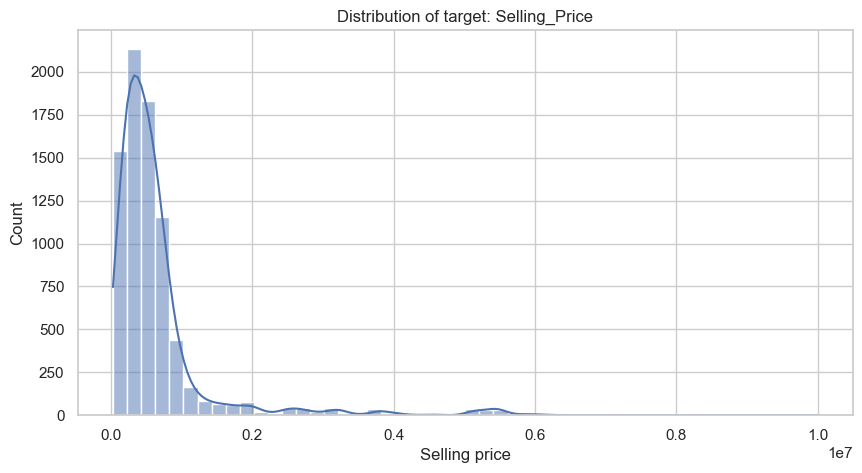

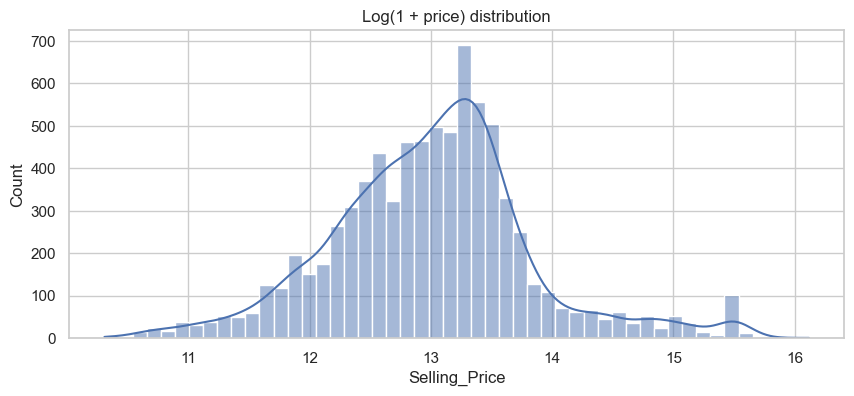

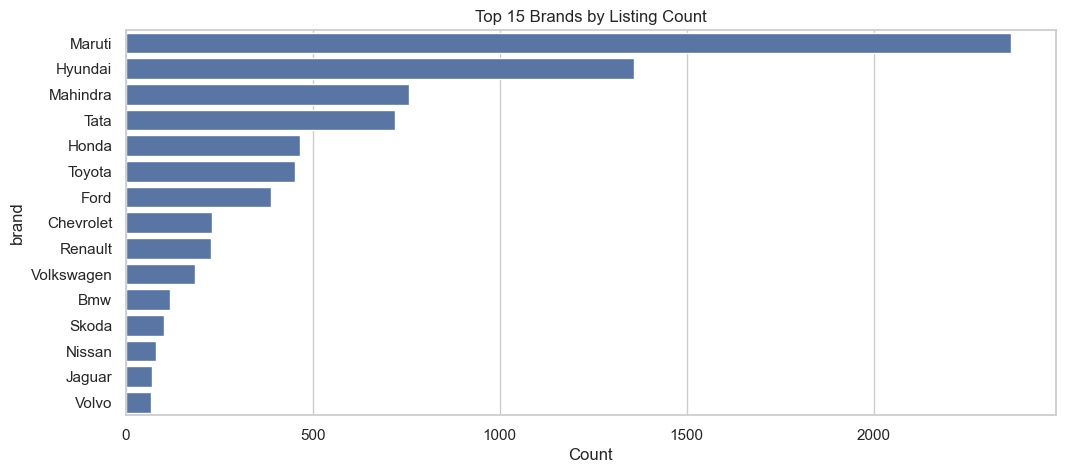

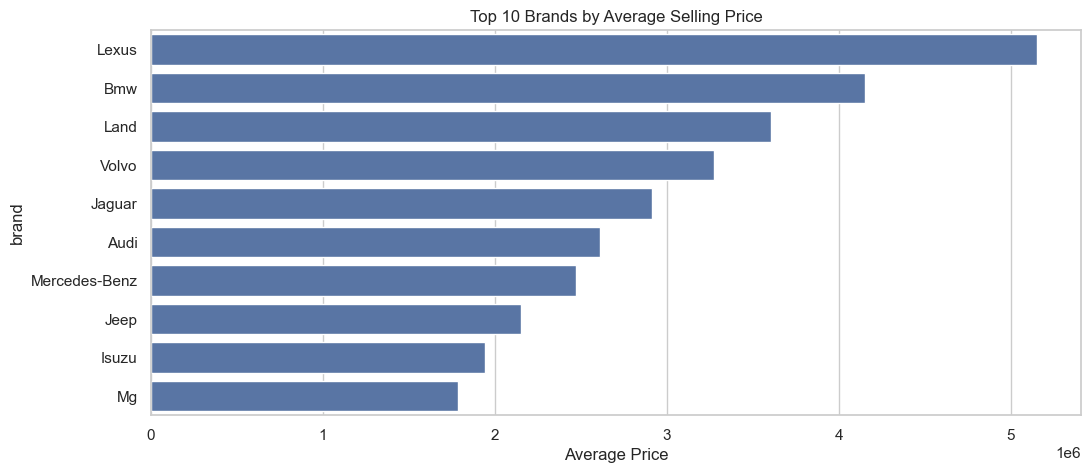

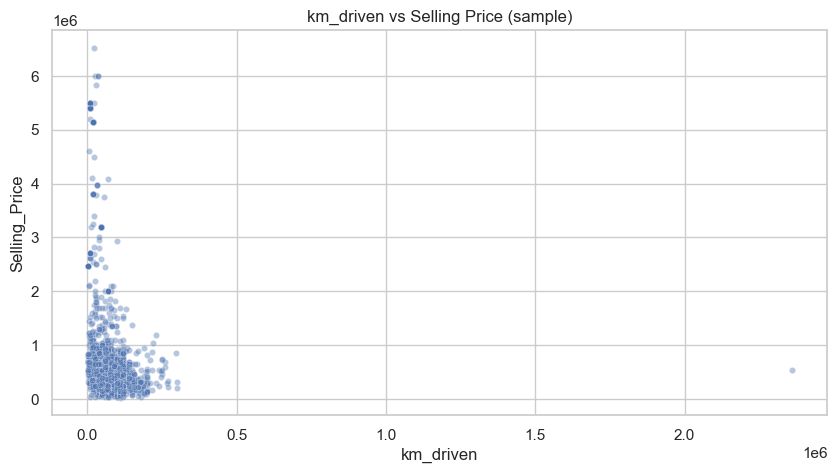

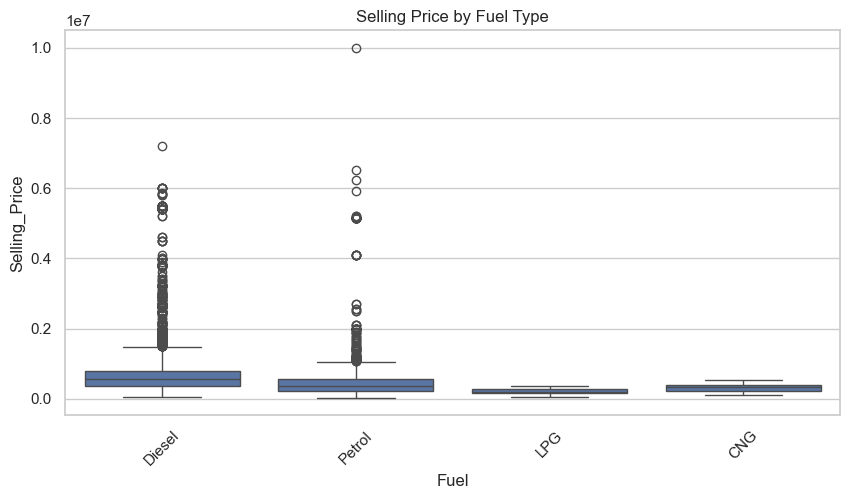

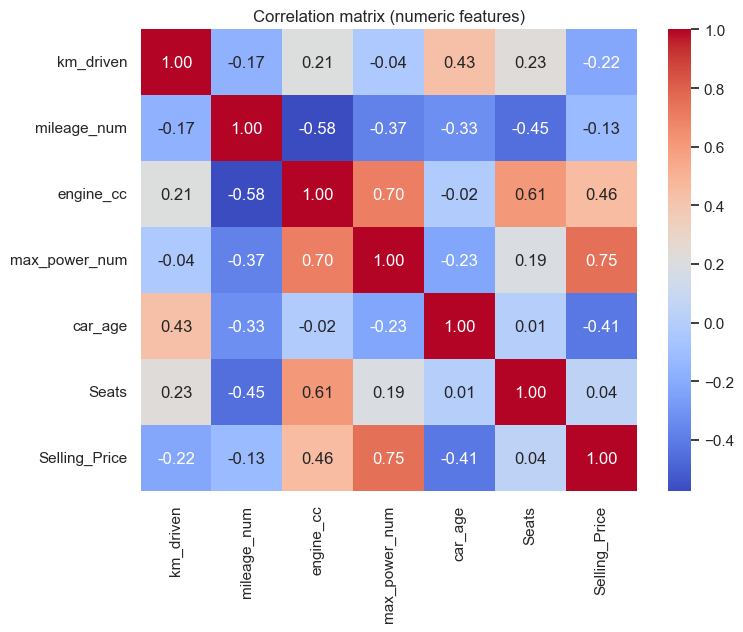

T-test Manual vs Automatic -> t=-27.848, p=0.000000
ANOVA across top 5 brands -> F=158.299, p=0.000000
Chi-square Owner vs Fuel -> chi2=32.819, p=0.001033


In [19]:
# 5) Detailed EDA & hypothesis testing
# 5.1 Distribution of target
plt.figure(figsize=(10,5))
sns.histplot(df[target_col].dropna(), kde=True, bins=50)
plt.title("Distribution of target: " + target_col)
plt.xlabel("Selling price")
plt.show()

# log-transform view
plt.figure(figsize=(10,4))
sns.histplot(np.log1p(df[target_col].dropna()), kde=True, bins=50)
plt.title("Log(1 + price) distribution")
plt.show()

# 5.2 Top brands by count
if 'brand' in df.columns:
    top_brands = df['brand'].value_counts().nlargest(15)
    plt.figure(figsize=(12,5))
    sns.barplot(x=top_brands.values, y=top_brands.index)
    plt.title("Top 15 Brands by Listing Count")
    plt.xlabel("Count")
    plt.show()

# 5.3 Average price by brand (top 10)
if 'brand' in df.columns:
    brand_avg = df.groupby('brand')[target_col].mean().sort_values(ascending=False).head(10)
    plt.figure(figsize=(12,5))
    sns.barplot(x=brand_avg.values, y=brand_avg.index)
    plt.title("Top 10 Brands by Average Selling Price")
    plt.xlabel("Average Price")
    plt.show()

# 5.4 Price vs km_driven scatter (sample for speed)
if 'km_driven' in df.columns:
    sample = df.dropna(subset=['km_driven', target_col]).sample(n=min(2000, len(df.dropna(subset=['km_driven', target_col]))), random_state=42)
    plt.figure(figsize=(10,5))
    sns.scatterplot(x='km_driven', y=target_col, data=sample, alpha=0.4, s=20)
    plt.title("km_driven vs Selling Price (sample)")
    plt.show()

# 5.5 Boxplot: Selling price by fuel type
fuel_col = None
for c in ['Fuel','fuel']:
    if c in df.columns:
        fuel_col = c
        break
if fuel_col:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=fuel_col, y=target_col, data=df[df[fuel_col].notna()])
    plt.title("Selling Price by Fuel Type")
    plt.xticks(rotation=45)
    plt.show()

# 5.6 Correlation heatmap for numeric features
num_for_corr = [c for c in ['km_driven','mileage_num','engine_cc','max_power_num','car_age','Seats', target_col] if c in df.columns]
if len(num_for_corr) >= 2:
    corr = df[num_for_corr].corr()
    plt.figure(figsize=(8,6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
    plt.title("Correlation matrix (numeric features)")
    plt.show()

# 5.7 Hypothesis tests examples
# T-test: Compare mean price between Manual and Automatic
trans_col = None
for c in ['Transmission','transmission']:
    if c in df.columns:
        trans_col = c
        break

if trans_col:
    manual_prices = df[df[trans_col].str.lower().str.contains('manual', na=False)][target_col].dropna()
    auto_prices = df[df[trans_col].str.lower().str.contains('automatic', na=False)][target_col].dropna()
    if len(manual_prices) > 10 and len(auto_prices) > 10:
        tstat, pval = ttest_ind(manual_prices, auto_prices, equal_var=False)
        print(f"T-test Manual vs Automatic -> t={tstat:.3f}, p={pval:.6f}")
    else:
        print("Not enough samples to perform t-test for transmission groups.")

# ANOVA: Price across top 5 brands
if 'brand' in df.columns:
    top5 = df['brand'].value_counts().nlargest(5).index.tolist()
    groups = [df[df['brand'] == b][target_col].dropna() for b in top5]
    if all(len(g)>10 for g in groups):
        fstat, p_anova = f_oneway(*groups)
        print(f"ANOVA across top 5 brands -> F={fstat:.3f}, p={p_anova:.6f}")
    else:
        print("Not enough samples for ANOVA across top 5 brands.")

# Chi-square: Owner vs Fuel (categorical association)
owner_col = None
for c in ['Owner','owner']:
    if c in df.columns:
        owner_col = c
        break
if owner_col and fuel_col:
    ct = pd.crosstab(df[owner_col].fillna('NA'), df[fuel_col].fillna('NA'))
    if ct.size > 1:
        chi2, p_chi, dof, _ = chi2_contingency(ct)
        print(f"Chi-square Owner vs Fuel -> chi2={chi2:.3f}, p={p_chi:.6f}")
    else:
        print("Contingency table too small for chi-square.")


In [23]:
# 6) Preprocessing pipeline for modeling
# Choose numeric and categorical features for modeling. Adjust if required.
numeric_features = [c for c in ['km_driven','mileage_num','engine_cc','max_power_num','car_age','Seats'] if c in df.columns]
categorical_features = []
preferred_cats = ['brand', 'Fuel', 'Transmission', 'Owner', 'Seller_Type', 'State', 'State_Name']
for c in preferred_cats:
    if c in df.columns:
        categorical_features.append(c)

# Reduce cardinality for brand (group low-frequency brands into 'Other')
if 'brand' in categorical_features:
    top_brands = df['brand'].value_counts().nlargest(15).index.tolist()
    df['brand'] = df['brand'].apply(lambda x: x if x in top_brands else 'Other')

print("Numeric features to be used:", numeric_features)
print("Categorical features to be used:", categorical_features)

# Drop rows missing the target
df_model = df.dropna(subset=[target_col]).copy()

# X and y
X = df_model[numeric_features + categorical_features].copy()
y = df_model[target_col].copy()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

# Transformers
# Transformers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


Numeric features to be used: ['km_driven', 'mileage_num', 'engine_cc', 'max_power_num', 'car_age', 'Seats']
Categorical features to be used: ['brand', 'Fuel', 'Transmission', 'Owner', 'Seller_Type']
Train shape: (6324, 11) Test shape: (1582, 11)


In [25]:
# 7) Model training & evaluation (Linear, Ridge, RandomForest, XGBoost-if-available)
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

# Try to import XGBoost if available
try:
    from xgboost import XGBRegressor
    models['XGBoost'] = XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
    print("XGBoost available and will be evaluated.")
except Exception as e:
    print("XGBoost not installed or failed to import. Skipping XGBoost. (Install xgboost to enable)")

results = []
pipelines = {}

for name, model in models.items():
    print(f"\nTraining {name} ...")
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    rmse = mean_squared_error(y_test, preds, squared=False)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results.append({'model': name, 'rmse': rmse, 'mae': mae, 'r2': r2})
    pipelines[name] = pipe
    print(f"{name} -> RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.4f}")

results_df = pd.DataFrame(results).sort_values('rmse').reset_index(drop=True)
display(results_df)
results_df.to_csv("model_results_initial.csv", index=False)
print("Saved model_results_initial.csv")


XGBoost not installed or failed to import. Skipping XGBoost. (Install xgboost to enable)

Training LinearRegression ...
LinearRegression -> RMSE: 355562.95, MAE: 206443.91, R2: 0.8182

Training Ridge ...
Ridge -> RMSE: 354431.71, MAE: 206903.94, R2: 0.8193

Training RandomForest ...
RandomForest -> RMSE: 102551.84, MAE: 60162.79, R2: 0.9849


,model,rmse,mae,r2
0,RandomForest,102551.840692,60162.793337,0.984874
1,Ridge,354431.712565,206903.942676,0.819323
2,LinearRegression,355562.950665,206443.911059,0.818168


Saved model_results_initial.csv


In [31]:
# 8) Quick hyperparameter tuning for RandomForest (small randomized search)
print("Hyperparameter tuning: RandomizedSearchCV (small search to keep runtime moderate)")

param_dist = {
    'model__n_estimators': randint(50, 200),
    'model__max_depth': randint(5, 30),
    'model__min_samples_split': randint(2, 10),
    'model__min_samples_leaf': randint(1, 5),
    'model__max_features': ['auto', 'sqrt', 'log2', 0.6, 0.8]
}

rf_pipe = Pipeline([('preprocessor', preprocessor), ('model', RandomForestRegressor(random_state=42))])
rs = RandomizedSearchCV(rf_pipe, param_distributions=param_dist, n_iter=6, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1, random_state=42, verbose=1)
rs.fit(X_train, y_train)

print("Best params (RandomForest):", rs.best_params_)
best_rf = rs.best_estimator_
pred_rf = best_rf.predict(X_test)
rmse_rf = mean_squared_error(y_test, pred_rf, squared=False)
mae_rf = mean_absolute_error(y_test, pred_rf)
r2_rf = r2_score(y_test, pred_rf)
print(f"Tuned RandomForest -> RMSE: {rmse_rf:.2f}, MAE: {mae_rf:.2f}, R2: {r2_rf:.4f}")

# Append tuned RF result to results_df and save
new_row = pd.DataFrame
results_df = results_df.sort_values('rmse').reset_index(drop=True)
display(results_df)
results_df.to_csv("model_comparison_final.csv", index=False)
print("Saved model_comparison_final.csv")


Hyperparameter tuning: RandomizedSearchCV (small search to keep runtime moderate)
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best params (RandomForest): {'model__max_depth': 11, 'model__max_features': 0.6, 'model__min_samples_leaf': 1, 'model__min_samples_split': 8, 'model__n_estimators': 156}
Tuned RandomForest -> RMSE: 117349.84, MAE: 67537.08, R2: 0.9802


,model,rmse,mae,r2
0,RandomForest,102551.840692,60162.793337,0.984874
1,Ridge,354431.712565,206903.942676,0.819323
2,LinearRegression,355562.950665,206443.911059,0.818168


Saved model_comparison_final.csv


In [32]:
# 9) Feature importance (from tuned RF if available) and interpretation
# Extract feature names from preprocessor (numeric + onehot cat names)
if 'best_rf' in locals():
    rf_model = best_rf.named_steps['model']
    # numeric names
    num_names = numeric_features
    # get one-hot categories
    ohe = best_rf.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
    cat_names = list(ohe.get_feature_names_out(categorical_features))
    feature_names = list(num_names) + cat_names
    importances = rf_model.feature_importances_
    fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)
    display(fi.head(20))
    fi.head(20).to_csv("feature_importances_top20.csv")
    print("Saved feature_importances_top20.csv")
else:
    print("Tuned RandomForest not available; extracting feature importances from baseline RandomForest if trained.")
    if 'RandomForest' in pipelines:
        rf_model = pipelines['RandomForest'].named_steps['model']
        num_names = numeric_features
        ohe = pipelines['RandomForest'].named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
        cat_names = list(ohe.get_feature_names_out(categorical_features))
        feature_names = list(num_names) + cat_names
        importances = rf_model.feature_importances_
        fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)
        display(fi.head(20))
        fi.head(20).to_csv("feature_importances_top20.csv")
        print("Saved feature_importances_top20.csv")


max_power_num             0.524140
car_age                   0.152851
Transmission_Automatic    0.085042
engine_cc                 0.057877
Transmission_Manual       0.050481
km_driven                 0.046739
mileage_num               0.022605
brand_Bmw                 0.016983
brand_Other               0.007904
Seller_Type_Dealer        0.006906
Seats                     0.004537
brand_Toyota              0.003838
Fuel_Petrol               0.003265
Seller_Type_Individual    0.003164
Fuel_Diesel               0.003077
Owner_First Owner         0.003047
brand_Jaguar              0.001512
brand_Tata                0.001440
Owner_Second Owner        0.001437
brand_Mahindra            0.000699
dtype: float64

Saved feature_importances_top20.csv


In [35]:
# 10) Save best performing model (choose lowest RMSE from results_df)
best_model_name = results_df.iloc[0]['model']
print("Best model from table:", best_model_name)

# Map name to pipeline
if best_model_name == 'RandomForest_Tuned' and 'best_rf' in locals():
    model_to_save = best_rf
elif best_model_name in pipelines:
    model_to_save = pipelines[best_model_name]
else:
    # fallback: the tuned RF
    model_to_save = best_rf if 'best_rf' in locals() else pipelines.get('RandomForest', None)

if model_to_save is not None:
    os.makedirs("models", exist_ok=True)
    save_path = os.path.join("models", "best_model.joblib")
    joblib.dump(model_to_save, save_path)
    print(f"Saved best model to {save_path}")
else:
    print("No model available to save.")


Best model from table: RandomForest
Saved best model to models\best_model.joblib


In [37]:
# Optional: quick predict example using the saved model
# Load it back and test on a few rows
try:
    m = joblib.load("models/best_model.joblib")
    sample_X = X_test.head(5)
    preds = m.predict(sample_X)
    print("Sample predictions:", preds)
    display(pd.DataFrame({'actual': y_test.head(5).values, 'predicted': preds}))
except Exception as e:
    print("Could not load or predict with saved model:", e)


Sample predictions: [557839.95       515953.32333333 173479.95       394949.98
 584909.95      ]


,actual,predicted
0,501000,557839.950000
1,440000,515953.323333
2,140000,173479.950000
3,476999,394949.980000
4,620000,584909.950000


In [41]:
# saving the trained Random Forest model
import joblib

# Save the model
joblib.dump(best_rf, "random_forest_model.pkl")

print("✅ Model saved successfully as random_forest_model.pkl")



✅ Model saved successfully as random_forest_model.pkl


In [43]:
# testing the loaded data
import joblib
model = joblib.load("random_forest_model.pkl")
print("✅ Model loaded successfully")


✅ Model loaded successfully
